In [1]:
import sys
print(sys.executable)

import numpy, scipy, matplotlib
print("numpy", numpy.__version__)
print("scipy", scipy.__version__)
print("matplotlib", matplotlib.__version__)


C:\Users\razan\anaconda3\envs\anaconda-2025.12-py3.13\python.exe
numpy 2.3.5
scipy 1.16.3
matplotlib 3.10.6


In [2]:
#libraries
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

# Step 1: Generate a synthetic extracellular recording that mimics the real data.
**Why synthetic data?** To benchmark denoisers fairly, I need the *true clean signal* to
compare against. Real recordings never come with a clean reference. So I build the clean
signal myself, add noise, denoise it, then compare back to the known clean version:

`clean → + noise → noisy → [denoise] → compare back to clean`

## Stage 1: Build a clean recording:
- A real extracellular action potential is **asymmetric**: a sharp, deep negative trough,
  then a smaller and slower positive rebound.
- Ricker is **symmetric**, so it can't match this. DoG builds the trough and rebound as two
  separate Gaussians, so I can control them independently (`peak_ratio` sets how big the
  rebound is relative to the trough).
- Also, `scipy.signal.ricker` was removed in recent SciPy versions, so it may not
  import. DoG is just `np.exp` — no dependency.

Template is normalised so the trough = **−1.0**, so the channel map can scale it cleanly

In [3]:
def make_spike_template (fs=20000, duration_ms=2.0,
                         trough_pos=0.4, trough_width=0.12,
                         peak_pos=0.6, peak_width=0.25, peak_ratio=0.4):
    """
    One extracellular AP template, normalised so teh trough (min) = -1.0.
    Built as a difference of gaussians : sharp negative trough + slower positive rebound. 
    possitions are fractions of the window(0..1).
    """
    n = int(fs * duration_ms / 1000)   # samples in the window
    t = np.linspace(0, 1, n)    # normalise time 0..1

    trough = -np.exp(-((t - trough_pos)**2) / (2 * trough_width**2))
    peak = peak_ratio * np.exp(-((t - peak_pos)**2) / (2 * peak_width**2))

    wave = trough + peak
    wave = wave / np.abs(wave.min())   # normalise so min = -1.0
    return t, wave

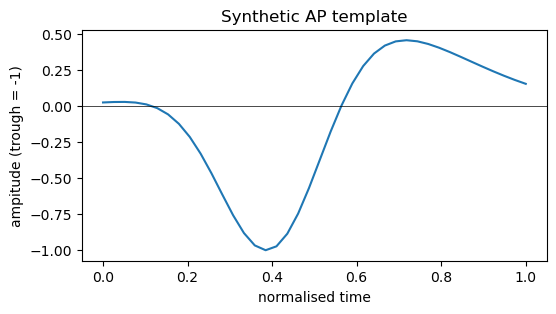

In [4]:
t, wave = make_spike_template()
plt.figure(figsize=(6,3))
plt.plot(t, wave)
plt.axhline(0, color='k', lw=0.5)
plt.xlabel("normalised time"); plt.ylabel("ampitude (trough = -1)")
plt.title("Synthetic AP template"); plt.show()

## Stage 2:  channel map (how strong the spike is on each channel):
`amp` = 32 numbers, one per electrode contact. Channel 19 = 1.0 (strongest), fading through
strong neighbours (9, 14, 25, 30) and weak ones (3, 10, 12, 16, 17, 32), and 0 on the rest.

**Physical meaning:** one fibre fires; contacts physically closer to it record a stronger
signal, farther ones weaker, distant ones nothing. So `amp` is the fibre's **spatial
footprint across the electrode**.

**Why this matters (the spine of the project):** each fibre has its own unique pattern across
the 32 channels — its spatial "fingerprint." Sorting tells fibres apart by comparing these
cross-channel patterns, not just spike shape. (My earlier result: F1 ~0.05 on 1 channel →
~0.51 with 3–5 channels.)

> **Viva one-liner:** Per-channel denoising treats channels independently, so it doesn't
> preserve the cross-channel amplitude ratios — and those ratios are exactly what sorting
> relies on. That's why I argue for **joint (multi-channel) denoising**, which cleans all
> channels together and can preserve the pattern.

In [5]:
# How strong the spike looks in each channel
n_channels = 32
amp = np.zeros(n_channels)  # 32 zeros - every channel starts silent 

# the good unit similart to the actual data
amp[18] = 1.0    # channel 19 (19 - 1 = index 18)

# strong neighbours (channels 9, 14, 25, 30)
amp[8] = 0.6   # channel 9
amp[13] = 0.45  # channel 14
amp[24] = 0.7  # channel 25
amp[29] = 0.5   # channel 30

# weak (channels 3, 10, 12, 16, 17, 32
amp[2] = 0.15   # channel 3
amp[9] = 0.1    # channel 10
amp[11] = 0.25  # channel 12
amp[15] = 0.16 # channel 16
amp[16] = 0.22  # channel 17
amp[31] = 0.24  # channel 32

for ch in [19, 9, 14, 25, 30, 3, 10, 12, 16, 17, 32]:
    print(f"channel {ch:2d} -> index {ch-1:2d} -> amplitude {amp[ch-1]}")

channel 19 -> index 18 -> amplitude 1.0
channel  9 -> index  8 -> amplitude 0.6
channel 14 -> index 13 -> amplitude 0.45
channel 25 -> index 24 -> amplitude 0.7
channel 30 -> index 29 -> amplitude 0.5
channel  3 -> index  2 -> amplitude 0.15
channel 10 -> index  9 -> amplitude 0.1
channel 12 -> index 11 -> amplitude 0.25
channel 16 -> index 15 -> amplitude 0.16
channel 17 -> index 16 -> amplitude 0.22
channel 32 -> index 31 -> amplitude 0.24


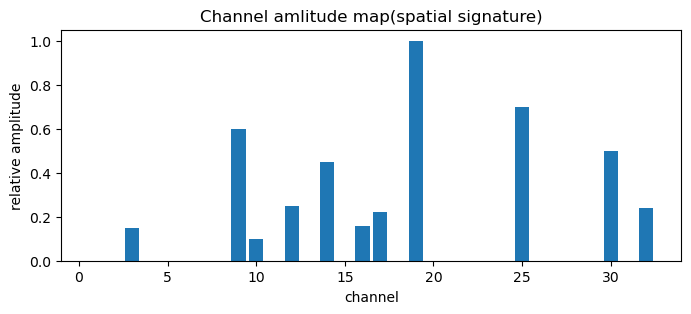

In [6]:
# plot
plt.figure(figsize=(8,3))
plt.bar(np.arange(1, n_channels+1), amp)
plt.xlabel("channel"); plt.ylabel("relative amplitude")
plt.title("Channel amlitude map(spatial signature)")
plt.show()

## Stage 3: Spike times (when spikes happen)
Evoked case: fibres fire at a fixed delay after each stimulus (TTL).
- phase 1 timing: 0.25Hz = 1 pulse every 4 s, 221 pulses
- `ttl_times = np.arange(n_pulses) * stim_period` -> 0, 4, 8, … 880 s.
- `spike_times = ttl_times + latency` — the **latency** is the travel delay from stimulus to
  electrode. It's fixed because it's the same fibre responding to the same stimulus each time.

Because I *define* these times, they are perfect **ground truth** for testing detection later.

In [7]:
# Spike time: when do these spike happen
fs = 20000 # HZ, must match the template
stim_period = 4.0  # seconds between pulses (0.25 Hz)
n_pulses = 221
latency = 0.003   # seconds - fixed delay from stimulus to spike (pick a realistic value, ~2-4ms)

# TTl (stimulus) times in seconds: 0, 4, 8 for 221 pulses
ttl_times = np.arange(n_pulses) * stim_period
spike_times = ttl_times + latency 

print("number of TTLs:", len(ttl_times))
print("first 3 TTL times (s):", ttl_times[:3])
print("last TTL time (s):", ttl_times[-1])
print("first 3 spikes times (s):", spike_times[:3]) 

number of TTLs: 221
first 3 TTL times (s): [0. 4. 8.]
last TTL time (s): 880.0
first 3 spikes times (s): [3.000e-03 4.003e+00 8.003e+00]


## Stage 4: assemble the recording
Empty (32 × N) canvas of zeros; for each spike, stamp `template × amp[ch]` onto every channel
at that spike's sample index. Result: clean multi-channel recording with the correct spatial
signature (channel 19 tallest at −1.0, scaling down correctly).

**Bug learned:** `rec[ch, start:end] += ...` uses `+=` (accumulate). Re-running the loop
without re-zeroing `rec` stacks spikes on top of themselves (trough came out −2.0 instead of
−1.0 — exactly doubled). Fix: zero the canvas *inside* the same cell, so it's safe to re-run.
General rule: any cell that uses `+=` is unsafe to re-run alone; exact 2×/3× values are the tell.


In [8]:
# Assemble the recording
n_dev_spikes = 10
dev_spikes = spike_times[:n_dev_spikes]

# recordings needs to be long enough to hold the last dev spike + a full template after it
duration_s = dev_spikes[-1] + 0.01   # last spike time + 10 ms padding 
n_samples = int(duration_s * fs)   # total samples in the recordings

rec = np.zeros((n_channels, n_samples))   # 32 X N canvas, all silent
print("recording shape:", rec.shape)

recording shape: (32, 720260)


In [9]:
# Stamping logic
""" 
for each spike: convert its time (seconds) to a sample index ( where in the array it starts)
add the template X each channel's amplitude at that position
"""
n_template = len(wave)   # how many samples the tempalte spans (40)

for t_spike in dev_spikes:
    start = int(t_spike * fs)    # seconds -> sample index
    end = start + n_template  # template occupes start;end

    # stamp onto every channel scaled by that channel's amplitude
    for ch in range(n_channels):
        rec[ch, start:end] += wave * amp[ch]

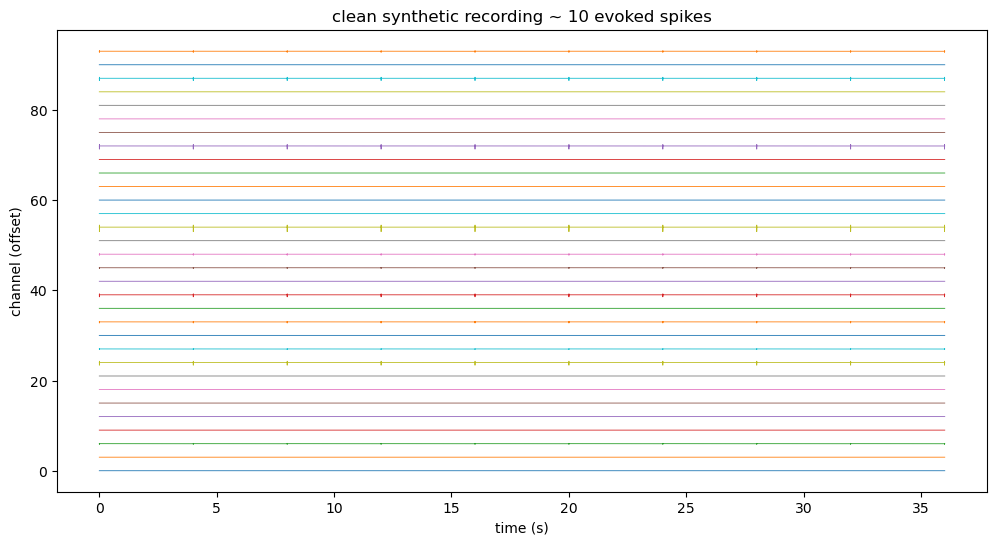

In [10]:
t_axis = np.arange(n_samples) / fs   # x-axis in seconds

plt.figure(figsize=(12, 6))
offset = 3   # vertical spacing so channels dont overlap
for ch in range(n_channels):
    plt.plot(t_axis, rec[ch] + ch * offset, lw=0.6)
plt.xlabel("time (s)"); plt.ylabel("channel (offset)")
plt.title("clean synthetic recording ~ 10 evoked spikes")
plt.show()

channel 19: trough = -1.000, peak-to-peak = 1.458
channel 25: trough = -0.700, peak-to-peak = 1.021
channel  9: trough = -0.600, peak-to-peak = 0.875
channel  3: trough = -0.150, peak-to-peak = 0.219
channel  1: trough = 0.000, peak-to-peak = 0.000


C:\Users\razan\anaconda3\envs\anaconda-2025.12-py3.13\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


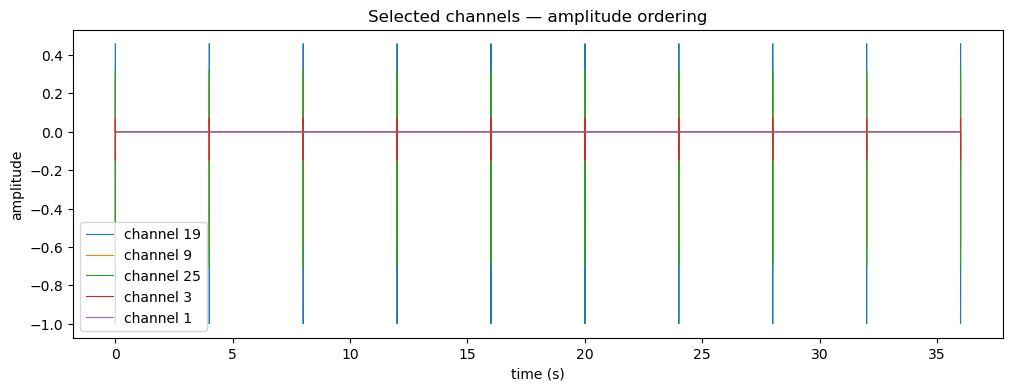

In [11]:
for ch in [18, 24, 8, 2, 0]:   # channels 19, 25, 9, 3, 1
    print(f"channel {ch+1:2d}: trough = {rec[ch].min():.3f}, peak-to-peak = {np.ptp(rec[ch]):.3f}")
plt.figure(figsize=(12, 4))
for ch in [18, 8, 24, 2, 0]:   # channel 19, 9, 25, 3, 1  (indices)
    plt.plot(t_axis, rec[ch], lw=0.8, label=f"channel {ch+1}")
plt.xlabel("time (s)"); plt.ylabel("amplitude")
plt.title("Selected channels — amplitude ordering")
plt.legend()
plt.show()

In [12]:
rec = np.zeros((n_channels, n_samples))

In [13]:
n_template = len(wave)

for t_spike in dev_spikes:
    start = int(t_spike * fs)
    end = start + n_template
    for ch in range(n_channels):
        rec[ch, start:end] += wave * amp[ch]

In [14]:
for ch in [18, 24, 8, 2, 0]:
    print(f"channel {ch+1:2d}: trough = {rec[ch].min():.3f}")

channel 19: trough = -1.000
channel 25: trough = -0.700
channel  9: trough = -0.600
channel  3: trough = -0.150
channel  1: trough = 0.000


## Stage 5: Add noise

`noise = np.random.normal(0, noise_std, rec.shape)` then `noisy = rec + noise`.

- `noise_std = 0.1` vs channel-19 spike depth 1.0 → spike ~10× noise (easy on ch19).
- Same noise on channel 3 (depth 0.15) → spike barely above noise (hard).
- **Key intuition:** the same noise makes strong channels easy and weak channels hard — which
  is why pooling across channels (joint denoising) matters. Later: sweep `noise_std` to plot
  performance vs SNR.


In [15]:
# One line of noise
noise_std = 0.1
noise = np.random.normal(0, noise_std, rec.shape) # random numbers, bell-curve distribtion, mean 0(noise is equally likely + or -), standard deviation 0.1( how big the wiggles are), and rec.shape so the noise array is exactly 32XN
noisy = rec + noise

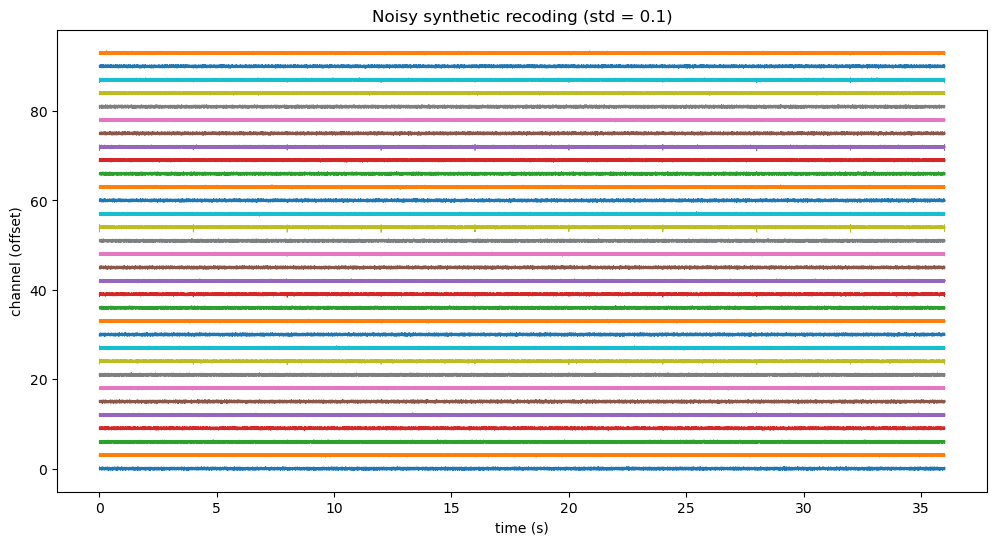

In [16]:
#plot it
t_axis = np.arange(n_samples) / fs
plt.figure(figsize=(12, 6))
offset = 3
for ch in range(n_channels):
    plt.plot(t_axis, noisy[ch] + ch * offset, lw=0.6)
plt.xlabel("time (s)"); plt.ylabel("channel (offset)")
plt.title("Noisy synthetic recoding (std = 0.1)")
plt.show()
    

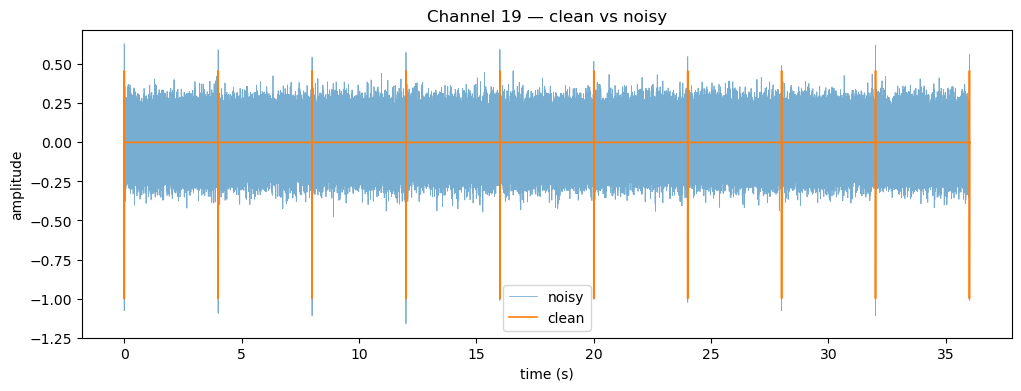

In [17]:
ch = 18  # channel 19 (the good unit)
plt.figure(figsize=(12, 4))
plt.plot(t_axis, noisy[ch], lw=0.6, alpha=0.6, label="noisy")
plt.plot(t_axis, rec[ch],   lw=1.2, label="clean")
plt.xlabel("time (s)"); plt.ylabel("amplitude")
plt.title("Channel 19 — clean vs noisy")
plt.legend()
plt.show()

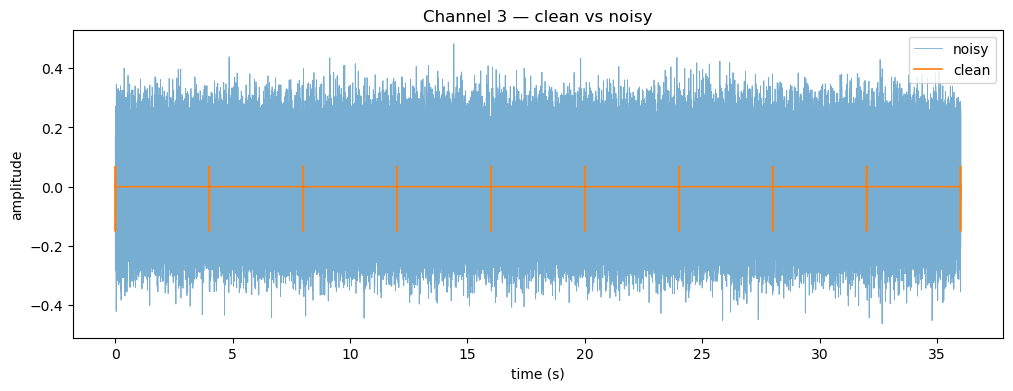

In [18]:
ch = 2 # channels 3 (weak)
plt.figure(figsize=(12, 4))
plt.plot(t_axis, noisy[ch], lw=0.6, alpha=0.6, label="noisy")
plt.plot(t_axis, rec[ch],   lw=1.2, label="clean")
plt.xlabel("time (s)"); plt.ylabel("amplitude")
plt.title("Channel 3 — clean vs noisy")
plt.legend()
plt.show()

## Stage 6: realistic noise
**Standard Gaussian white noise** distributions do not accurately mimic real extracellular neural or peripheral nerve preparations, as they assume a flat power spectral density that fails to challenge filters in-band. Electrophysiological environments present a multi-layered noise profile [Buccino & Einevoll., 2020].To construct high-fidelity synthetic data, three physical layers are added: **Aperiodic pink (\(1/f\))** noise to represent the combined effect of electrode-tissue thermal impedance and un-sortable, distant background Multi-Unit Activity (MUA). **Deterministic mains interference (50 Hz)** to simulate ambient electromagnetic leakage. An adjustable spatial cross-channel correlation coefficient ('knob') to split the noise into independent thermal channel fluctuations and global, common-mode components. This control sets the conditions under which purely temporal filters fail and multi-channel spatial methods, such as Common Average Referencing (CAR)—become advantageous [Ludwig et al., 2009].

### White noise
`np.random.normal`. Equal power at all frequencies (flat spectrum). Looks like uniform fuzz, no slow structure. Baseline case, but not realistic on its own.
### Pink (1/f) noise
More power at low frequencies, less at high (power falls off as 1/f). Looks like slow wandering/drift rather than uniform fuzz. Real neural background noise is 1/f, so this is more realistic than white.
Built via FFT: take white noise to the frequency domain (`np.fft.rfft`), divide each component by sqrt(frequency) to suppress high frequencies and boost low, transform back (`np.fft.irfft`). Skip frequency bin 0 (DC term) to avoid dividing by zero. So pink is white noise with its frequency content reshaped.

In [19]:
def make_pink_noise(n_samples, fs):
    """
    Pink (1/f) noise: white noise shaped so power falls off as 1.frequency.
    method: FFT white noise -> divide by sqrt(f) -> inverse FFT.
    """
    # white noise first
    white = np.random.normal(0, 1, n_samples)

    # frequency domain
    spectrum = np.fft.rfft(white)

    # build the frequencies for each spectrum bin
    freqs = np.fft.rfftfreq(n_samples, d=1/fs)

    # scale: divide each frequency component by sqrt(f), this is what titls the flat white spectrum into 1/f pink. 
    scaling = np.ones_like(freqs)
    scaling[1:] = 1 / np.sqrt(freqs[1:])  # skip index 0 to avoid /0
    spectrum_pink = spectrum * scaling

    # time domain
    pink = np.fft.irfft(spectrum_pink, n=n_samples)

    # normalise to std = 1 so itscales later like white noise
    pink = pink / np.std(pink)
    return pink

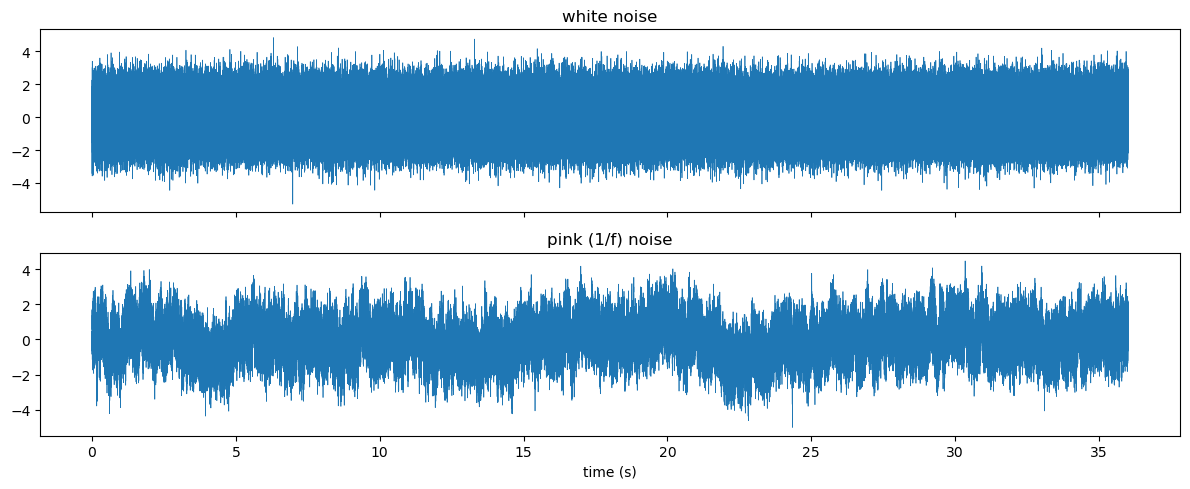

In [20]:
n = n_samples    #reusing the recording length
white = np.random.normal(0, 1, n)
pink = make_pink_noise(n, fs)

fig, ax = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
ax[0].plot(np.arange(n)/fs, white, lw=0.5); ax[0].set_title("white noise")
ax[1].plot(np.arange(n)/fs, pink, lw=0.5); ax[1].set_title("pink (1/f) noise")
ax[1].set_xlabel("time (s)")
plt.tight_layout(); plt.show()

### 50 Hz mains
UK mains electricity is 50 Hz (60 Hz in US). Powered devices near the rig radiate a 50 Hz field that the electrode and cables pick up. A steady hum on top of the signal. Modelled as a sine wave: `mains_amp * np.sin(2*pi*50*t)`. Present in almost all real recordings.

Put in the shared (common-mode) part because the external field hits all channels at once, every channel picks up nearly the same hum. This is exactly the kind of noise CAR/CMR can remove.


In [21]:
# 50 Hz mains hum
def make_mains(n_samples, fs, mains_amp=0.2, freq=50):
    """
    50 Hz mains interference, A sine wave at the mains frequency 
    """

    t = np.arange(n_samples) / fs   # time in seconds
    mains = mains_amp * np.sin(2 * np.pi * freq * t)
    return mains

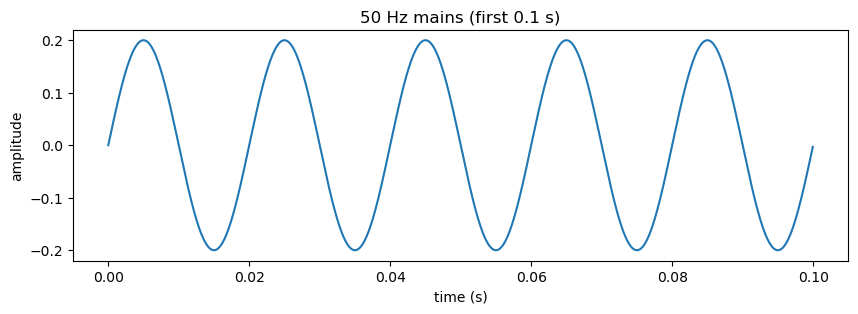

In [22]:
mains = make_mains(n_samples, fs)
n_show = int(0.1 * fs)   # first 0.1 s

plt.figure(figsize=(10, 3))
plt.plot(np.arange(n_show)/fs, mains[:n_show])
plt.xlabel("time (s)"); plt.ylabel("amplitude")
plt.title("50 Hz mains (first 0.1 s)")
plt.show()

### Cross-channel structure — `common_frac`
Controls how much noise is shared across channels (common-mode) vs independent per channel.
- 0.0 = all independent (each channel its own noise)
- 1.0 = all shared (same noise on every channel)
- 0.5 = half and half (sensible default; real recordings have both)

Why it matters:
- Shared noise is EASIER to remove: a multi-channel method can compare channels, see the same wiggle on all of them, and subtract it. (Only *some* channels show a real spike, so anything on *all* channels is noise.)
- Independent noise is HARDER: nothing shared across channels to exploit.

This is the knob that sets up the central experiment: with high common_frac, a joint (multi-channel) denoiser should beat a per-channel one, because only the joint method can see across channels.

In [23]:
# now combine white + pink + 50 Hz noise
def make_noise(n_channels, n_samples, fs, white_std=0.1, pink_std=0.1, mains_amp=0.05, common_frac=0.5):
    """
    layered noise for a multi-channel recording
    - white + pink + 50 Hz mains
    - common_frac sets how much noise is shared across channels (common-mode)
       vs independent per channel. 0 = all independent, 1 = all shared.
    returns array shape (n_channels, n_samples)
    """
    noise = np.zeros((n_channels, n_samples))

    # independent part: different noise on each channel
    for ch in range(n_channels):
        w = white_std * np.random.normal(0, 1, n_samples)
        p = pink_std * make_pink_noise(n_samples, fs)
        noise[ch] = (1 - common_frac) * (w + p)

    # common-mode part: ONE noise trace shared by all channels
    w_common = white_std * np.random.normal(0, 1, n_samples)
    p_common = pink_std * make_pink_noise(n_samples, fs)
    mains = make_mains(n_samples, fs, mains_amp)
    shared = w_common + p_common + mains

    # add the same shared trace to every channel
    for ch in range(n_channels):
        noise[ch] += common_frac * shared

    return noise

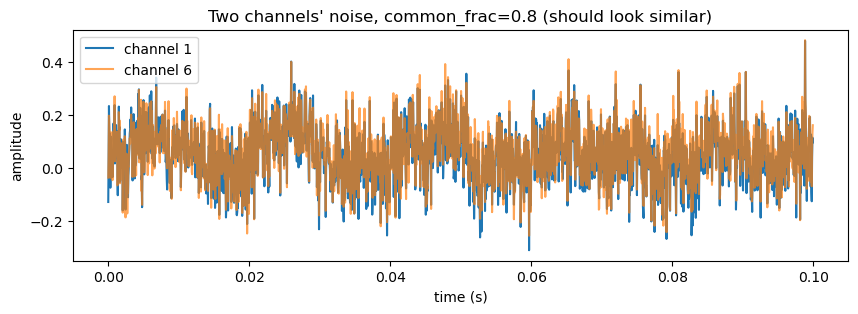

In [24]:
test_noise = make_noise(n_channels, n_samples, fs, common_frac=0.8)
n_show = int(0.1 * fs)
plt.figure(figsize=(10, 3))
plt.plot(np.arange(n_show)/fs, test_noise[0, :n_show], label="channel 1")
plt.plot(np.arange(n_show)/fs, test_noise[5, :n_show], label="channel 6", alpha=0.7)
plt.xlabel("time (s)"); plt.ylabel("amplitude")
plt.title("Two channels' noise, common_frac=0.8 (should look similar)")
plt.legend()
plt.show()


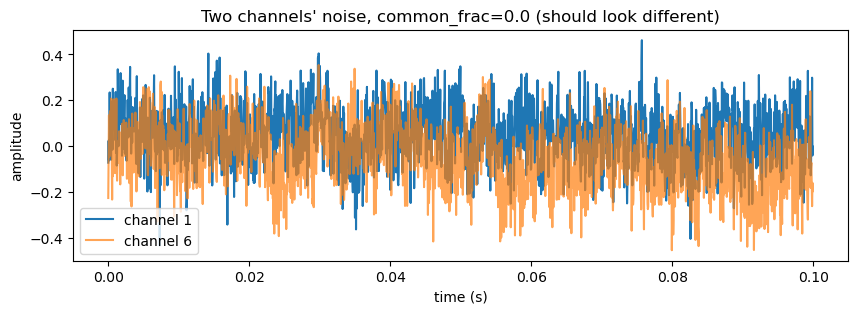

In [25]:
test_noise = make_noise(n_channels, n_samples, fs, common_frac=0.0)

n_show = int(0.1 * fs)
plt.figure(figsize=(10, 3))
plt.plot(np.arange(n_show)/fs, test_noise[0, :n_show], label="channel 1")
plt.plot(np.arange(n_show)/fs, test_noise[5, :n_show], label="channel 6", alpha=0.7)
plt.xlabel("time (s)"); plt.ylabel("amplitude")
plt.title("Two channels' noise, common_frac=0.0 (should look different)")
plt.legend()
plt.show()

In [26]:
print("channel 1 std:", test_noise[0].std())
print("channel 6 std:", test_noise[5].std())
print("any nonzero in ch6?:", np.any(test_noise[5] != 0))


channel 1 std: 0.14156313841661583
channel 6 std: 0.1414492178452186
any nonzero in ch6?: True


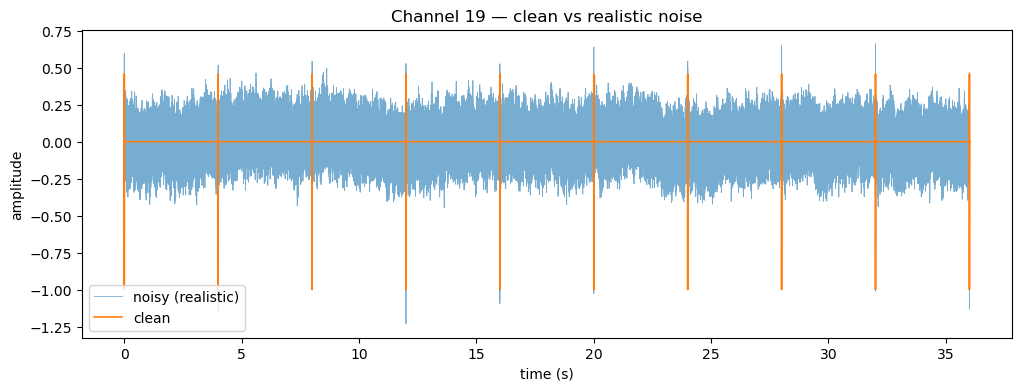

In [27]:
noise = make_noise(n_channels, n_samples, fs, common_frac=0.5)
noisy = rec + noise
ch = 18  # channel 19
t_axis = np.arange(n_samples) / fs
plt.figure(figsize=(12, 4))
plt.plot(t_axis, noisy[ch], lw=0.6, alpha=0.6, label="noisy (realistic)")
plt.plot(t_axis, rec[ch],   lw=1.2, label="clean")
plt.xlabel("time (s)"); plt.ylabel("amplitude")
plt.title("Channel 19 — clean vs realistic noise")
plt.legend()
plt.show()

## Admore sines

In [28]:
def make_mains(n_samples, fs, mains_amp=0.05, base_freq=50, n_harmonics=4):
    """
    Mains interference: 50 Hz + harmonics (100, 150, 200 Hz).
    Each harmonic n has amplitude mains_amp/n (higher harmonics weaker).
    """
    t = np.arange(n_samples) / fs
    mains = np.zeros(n_samples)
    for n in range(1, n_harmonics + 1):      # n = 1, 2, 3, 4
        freq = base_freq * n                 # 50, 100, 150, 200
        amp = mains_amp / n                  # full, half, third, quarter
        mains += amp * np.sin(2 * np.pi * freq * t)
    return mains

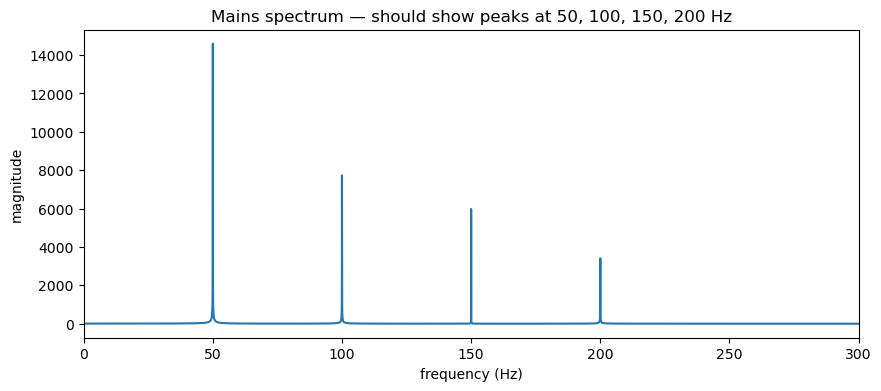

In [29]:
mains = make_mains(n_samples, fs)
# frequency spectrum
spectrum = np.abs(np.fft.rfft(mains))
freqs = np.fft.rfftfreq(n_samples, d=1/fs)

plt.figure(figsize=(10, 4))
plt.plot(freqs, spectrum)
plt.xlim(0, 300)           # zoom to 0-300 Hz so we can see the peaks
plt.xlabel("frequency (Hz)"); plt.ylabel("magnitude")
plt.title("Mains spectrum — should show peaks at 50, 100, 150, 200 Hz")
plt.show()

In [30]:
test = make_noise(n_channels, n_samples, fs, common_frac=0.5)
print("shape:", test.shape)
print("channel 0 std:", test[0].std())

shape: (32, 720260)
channel 0 std: 0.10083721689711374


# Step 2: Denoising
Remove the noise and score each method's performance using RMSE.
`clean -> + noise -> noisy -> denoise -> score against clean`
After building the clean signal (ground truth), measure how close each denoiser gets to the clean signal.  

## The contract
Every denoiser has the same shape: `denoise(noisy, fs) -> denoised`, input and output both (32 x N). Same signature means they're swappable and the same evaluation scores all of them.
### Evaluation metric to compare the denoisers: **RMSE**
Root mean squared error between the denoised signal and the clean truth. It captures noise left behind and signal damage; both increase RMSE. `rmse = sqrt(mean((denoised - clean)^2))`. Lower RMSE means closer to the truth, consequently a better denoiser. 
**Limitation:** 
RMSE averages over all 720, 260 samples per channel. But only ~400 of those samples contain a spike (10 spikes x 40 sample template = 0.05% of the recording). The other 99.95% is noise in the gaps between spikes.
So, the average is dominated by the noise. Every channel scored ~0.044, including channel 1, which has **no spike at all**. If RMSE measured spike preservation, a channel with the biggest spike and a channel with no spike would score differently, but they didn't.
**Conclusion:** RMSE measures how much noise is left, not whether the spike survived. It is a noise-removal metric, not a spike-preservation metric.
**To fix this,** instead of averaging over the whole recording, look at the spike itself

In [31]:
print(fs, n_channels, n_samples)
print("noisy shape:", noisy.shape)

20000 32 720260
noisy shape: (32, 720260)


## First: Bandpass filter
The spikes are fast and sharp transients; they live in a specific frequency band, roughly 300-3000 Hz. The noise is spread across all frequencies: pink noise dominates the low end (slow drift, below 300 Hz), and there's hiss up high. **A bandpass filter** keeps the 300-3000 Hz band and discards everything outside of it, so it strips the low-frequency pink drift and high-frequency junk, leaving the spikes band cleaner. 


In [32]:
from scipy.signal import butter, filtfilt

def butter_bandpass(lowcut, highcut, fs, order=4):
    return butter(order, [lowcut, highcut], fs=fs, btype='band')

def denoise_bandpass(noisy, fs, lowcut=300, highcut=3000, order=4):
    """
    Per-channel bandpass filter (300-3000Hz). Keeps the spike band, removes low-freq drift and high-freq hiss.
    filtfil = zero phase shift, so spike timing is preserved.
    input/output: (n_channels, n_samples).
    """
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    denoised = filtfilt(b, a, noisy, axis=1)
    return denoised

In [33]:
denoised = denoise_bandpass(noisy, fs)
print("shape", denoised.shape)

shape (32, 720260)


C:\Users\razan\anaconda3\envs\anaconda-2025.12-py3.13\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


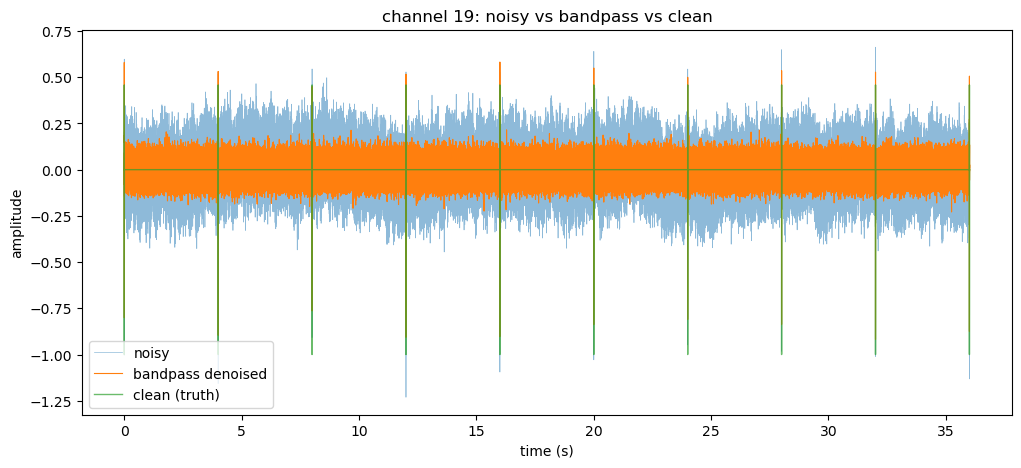

In [34]:
ch = 18  # channel 19
t_axis = np.arange(n_samples) / fs

plt.figure(figsize=(12, 5))
plt.plot(t_axis, noisy[ch],  lw=0.5, alpha=0.5, label="noisy")
plt.plot(t_axis, denoised[ch], lw=0.8, label="bandpass denoised")
plt.plot(t_axis, rec[ch],  lw=1.0, alpha=0.7, label="clean (truth)")
plt.xlabel("time (s)"); plt.ylabel("amplitude")
plt.title("channel 19: noisy vs bandpass vs clean")
plt.legend()
plt.show()

In [35]:
print("clean spike trough:", rec[18].min())
print("denoised spike trough:", denoised[18].min())

clean spike trough: -1.0
denoised spike trough: -0.9175702385168669


In [36]:
denoised_150 = denoise_bandpass(noisy, fs, lowcut=150)
print("denoised trough (lowcut=150):", denoised_150[18].min())

denoised trough (lowcut=150): -1.0033288664670885


## Evaluation Metrics 
Two matrics where used:
### Metric 1: RMSE (measures noise removal)
`rmse = sqrt(mean((denoised - clean)^2))`, averaged over all 720,260 samples per channel. Lower = closer to the clean truth.

It correctly showed bandpass 0.102 → 0.044, bandpass+CMR → 0.032, and the whole common_frac sweep.

**But it does not measure spike preservation.** Spikes occupy only ~400 samples (10 spikes × 40) out of 720,260 — 0.05% of the recording. The other 99.95% is background noise. So the average is dominated by noise; whether the spike survives barely moves it.
per-channel RMSE after bandpass:

| channel | spike | RMSE |
|---|---|---|
| 1 | none | 0.0440 |
| 3 | 0.15 | 0.0440 |
| 19 | 1.00 | 0.0436 |
| 25 | 0.70 | 0.0439 |

Channel 19 has the biggest spike; channel 1 has no spike at all, but they both show the same score. RMSE is counting baseline noise points, not spike points.

### Metric 2: spike_amplitude (measures spike preservation)

To measure the spike, look at the spike. This function takes the trough only inside the 40-sample windows where spikes are known to be (using ground-truth spike times), averaged over all 10 spikes.

**First attempt used `data.min()` on the whole channel** — but that finds the deepest point *anywhere*, usually a noise dip rather than the spike. Restricting to known spike windows fixed it:

| channel | `.min()` whole channel | spike windows |
|---|---|---|
| 19 | 94% | 86% |
| 3 | 147% | 109% |
| 10 | 199% | 117% |
| 1 (silent) | -0.207 | -0.088 |

The strong-channel number dropped from 94% to 86%. `.min()` was finding noise dips that made the spike look better preserved than it was.

### Results: bandpass spike preservation

| channel | clean | bandpass | preserved |
|---|---|---|---|
| 19 | -1.000 | -0.856 | 86% |
| 25 | -0.700 | -0.605 | 86% |
| 9 | -0.600 | -0.518 | 86% |
| 3 | -0.150 | -0.164 | 109% |
| 10 | -0.100 | -0.117 | 117% |
| 1 (silent) | 0.000 | -0.088 | (no spike) |

**Strong channels: 86% preserved.** Bandpass costs ~14% of amplitude, consistently so the ratios between strong channels survive.

**Weak channels: >100%.** Not preservation. The in-window noise (~0.09, measured on silent channel 1) is comparable to the spike itself (0.10–0.15), so it inflates the measured trough. On these channels, the spike cannot be cleanly measured or recovered by per-channel filtering, even knowing exactly where it is.

### Takeaway

RMSE and spike_amplitude answer different questions — noise removal vs spike preservation. Both are needed. RMSE is tier 1 of the four-tier evaluation plan; tiers 2–4 (cross-channel fidelity, detection/sorting, distinctiveness) measure what neither of these can.

Where noise is comparable to signal, per-channel methods have nothing to work with. That's the case for multi-channel denoising.

In [37]:
# RMSE
def rmse(denoised, clean):
    return np.sqrt(np.mean((denoised - clean) ** 2))

print("RMSE noisy vs clean:", rmse(noisy, rec))
print("RMSE bandpass vs clean:", rmse(denoised, rec))
print("RMSE bandpass -150 vs clean:", rmse(denoised_150, rec))

RMSE noisy vs clean: 0.10163187616952492
RMSE bandpass vs clean: 0.044852471232788606
RMSE bandpass -150 vs clean: 0.04825772992026734


In [38]:
# RMSE per channel
print("channel,  noisy RMSE,  bandpass RMSE")
for ch in range(n_channels):
    noisy_rmse = rmse(noisy[ch], rec[ch])  # one channel
    bp_rmse = rmse(denoised[ch], rec[ch])
    print(f" ch {ch+1:2d},     {noisy_rmse:.4f},      {bp_rmse:.4f}")

channel,  noisy RMSE,  bandpass RMSE
 ch  1,     0.1042,      0.0438
 ch  2,     0.1002,      0.0446
 ch  3,     0.1013,      0.0454
 ch  4,     0.1010,      0.0451
 ch  5,     0.1003,      0.0453
 ch  6,     0.0974,      0.0451
 ch  7,     0.1039,      0.0448
 ch  8,     0.1015,      0.0449
 ch  9,     0.1042,      0.0444
 ch 10,     0.1011,      0.0445
 ch 11,     0.1014,      0.0450
 ch 12,     0.1040,      0.0451
 ch 13,     0.1011,      0.0444
 ch 14,     0.0992,      0.0448
 ch 15,     0.1019,      0.0449
 ch 16,     0.0994,      0.0446
 ch 17,     0.1025,      0.0446
 ch 18,     0.1036,      0.0449
 ch 19,     0.1003,      0.0454
 ch 20,     0.0999,      0.0446
 ch 21,     0.1018,      0.0451
 ch 22,     0.1017,      0.0445
 ch 23,     0.1023,      0.0449
 ch 24,     0.1010,      0.0454
 ch 25,     0.1004,      0.0450
 ch 26,     0.1026,      0.0447
 ch 27,     0.1022,      0.0453
 ch 28,     0.1001,      0.0447
 ch 29,     0.1019,      0.0450
 ch 30,     0.1023,      0.0448
 ch

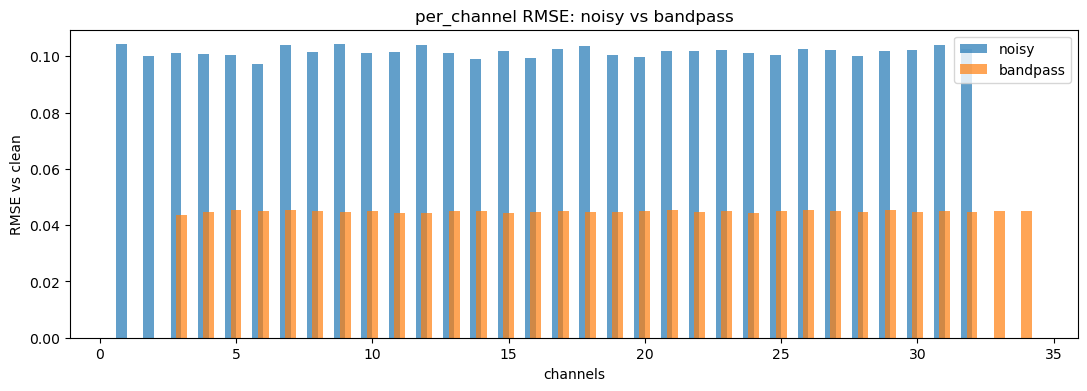

In [39]:
# plot
noisy_per_ch = np.array([rmse(noisy[ch], rec[ch]) for ch in range(n_channels)])
bp_per_ch = np.array([rmse(denoised[ch], rec[ch]) for ch in range(n_channels)])

x = np.arange(1, n_channels+1)
plt.figure(figsize=(13, 4))
plt.bar(x - 0.2, noisy_per_ch, width=0.4, label="noisy", alpha=0.7)
plt.bar(x + 2, bp_per_ch, width=0.4, label="bandpass", alpha=0.7)
plt.xlabel("channels"); plt.ylabel("RMSE vs clean")
plt.title("per_channel RMSE: noisy vs bandpass")
plt.legend()
plt.show()

In [40]:
#look at the spike instead of the whole recording (so look at the spike amplitude specificcaly)
print("channel,    clean trough,    bandpass trough,      % preserved")
for ch in [18, 24, 8, 2, 9, 0]:   # ch19, 25, 9, 3, 10, 1 (stron, weak, silent channels)
    clean_trough = rec[ch].min()
    bp_trough  = denoised[ch].min()
    if clean_trough !=0:
        pct = 100 * bp_trough / clean_trough
        print(f" ch {ch+1:2d},         {clean_trough:.3f},        {bp_trough:.3f},                {pct:.0f}%")
    else:
        print(f"  ch {ch+1:2d},        {clean_trough:.3f},        {bp_trough:.3f},                 (silent)")

channel,    clean trough,    bandpass trough,      % preserved
 ch 19,         -1.000,        -0.918,                92%
 ch 25,         -0.700,        -0.686,                98%
 ch  9,         -0.600,        -0.561,                94%
 ch  3,         -0.150,        -0.210,                140%
 ch 10,         -0.100,        -0.216,                216%
  ch  1,        0.000,        -0.189,                 (silent)


In [41]:
def spike_amplitude(data, spike_times, fs, n_template=40):
    """
    Mean spike trough, measured only inside known spike windows.
    """
    troughs = []
    for t_spike in spike_times:
        start = int(t_spike * fs)
        end = start + n_template
        troughs.append(data[start:end].min())   
    return np.mean(troughs)

In [42]:
print("channel | clean  | bandpass | % preserved")
for ch in [18, 24, 8, 2, 9, 0]:
    clean_amp = spike_amplitude(rec[ch], dev_spikes, fs)
    bp_amp    = spike_amplitude(denoised[ch], dev_spikes, fs)
    if clean_amp != 0:
        print(f"  ch {ch+1:2d}  | {clean_amp:6.3f} | {bp_amp:6.3f} | {100*bp_amp/clean_amp:5.0f}%")
    else:
        print(f"  ch {ch+1:2d}  | {clean_amp:6.3f} | {bp_amp:6.3f} | (silent)")

channel | clean  | bandpass | % preserved
  ch 19  | -1.000 | -0.855 |    86%
  ch 25  | -0.700 | -0.622 |    89%
  ch  9  | -0.600 | -0.517 |    86%
  ch  3  | -0.150 | -0.168 |   112%
  ch 10  | -0.100 | -0.147 |   147%
  ch  1  |  0.000 | -0.072 | (silent)


## Second: CMR (Common Median Reference) 
It takes the median across all channels at each time point subtract it from every channel. 
Common median has improved SNR for spike detection and doesn't generate spurious spikes the way mean-based referencing can when there are large transients Rolston, Gross, & Potter, 2009; Ludwig et al 2009). Therefore, CMR is more suitable for this data than CAR. CAR takes the average (mean) across all channels at each time point subtract it from every channel. 
### WHy CMR is good for extracellular recordings?
Real extracellular neural recordings are heavily corrupted by environmental noise sources that swamp the tiny electrical signals produced by nerves or neurons. According to Rolston, Gross, and Potter (2009), acts as a spatial filter that removes shared biological and 50/60 Hz noise without causing large baseline shifts or generating spurious spikes. By utilising the median instead of the mean, this algorithm resists outlier signals to prevent massive localised action potentials from contaminating adjacent recording channels. While offering high signal integrity, the method introduces slight computational overhead and a marginally higher baseline RMS noise floor.

In [43]:
def denoise_cmr(noisy, fs=None):
    """
    Common Median Reference (CMR): at each time point, subtract the median across channels,
    remove common-mode (shared) noise; spikes survive because they appear on only some channels, so dont dominate the median
    """
    reference = np.median(noisy, axis=0)   # median across channels -> shape 
    denoised = noisy - reference   # broadcast: subtract from every channel
    return denoised 

In [44]:
cmr_denoised = denoise_cmr(noisy)
print("Shape:", cmr_denoised.shape)

Shape: (32, 720260)


In [45]:
# Overall RMSE vs bandpass
print("RMSE noisy: ", rmse(noisy, rec))
print(" RMSE bandpass: ", rmse(denoised, rec))
print("RMSE CMR: ", rmse(cmr_denoised, rec))

RMSE noisy:  0.10163187616952492
 RMSE bandpass:  0.044852471232788606
RMSE CMR:  0.07027163369474125


In [46]:
print("channel,   clean,   bandpass,   CMR")
for ch in [18, 24, 8, 2, 9, 0]:   
    print(f" ch {ch+1:2d},     {rec[ch].min():.3f},    {denoised[ch].min():.3f},   {cmr_denoised[ch].min():.3f}")

channel,   clean,   bandpass,   CMR
 ch 19,     -1.000,    -0.918,   -0.997
 ch 25,     -0.700,    -0.686,   -0.803
 ch  9,     -0.600,    -0.561,   -0.655
 ch  3,     -0.150,    -0.210,   -0.341
 ch 10,     -0.100,    -0.216,   -0.377
 ch  1,     0.000,    -0.189,   -0.339


In [47]:
print("RMSE noisy:    ", rmse(noisy, rec))
print("RMSE bandpass: ", rmse(denoised, rec))
print("RMSE CMR:      ", rmse(cmr_denoised, rec))

RMSE noisy:     0.10163187616952492
RMSE bandpass:  0.044852471232788606
RMSE CMR:       0.07027163369474125


In [48]:
# How about bandpass then CMR combined?
bp = denoise_bandpass(noisy, fs)
cmr = denoise_cmr(noisy)

# combined: bandpass first, them CMR on the bandpass result
bp_then_cmr = denoise_cmr(denoise_bandpass(noisy, fs))
print("RMSE noisy:          ", rmse(noisy, rec))
print("RMSE bandpass:       ", rmse(bp, rec))
print("RMSE CMR alone:      ", rmse(cmr, rec))
print("RMSE bandpass+CMR:   ", rmse(bp_then_cmr, rec))

RMSE noisy:           0.10163187616952492
RMSE bandpass:        0.044852471232788606
RMSE CMR alone:       0.07027163369474125
RMSE bandpass+CMR:    0.03148042701460108


In [49]:
cmr_then_bp = denoise_bandpass(denoise_cmr(noisy), fs)
print("RMSE CMR+bandpass:   ", rmse(cmr_then_bp, rec))

RMSE CMR+bandpass:    0.03154606042431447


In [50]:
# Try at five different noise settings ( parameter sweep)
for cf in [0.0, 0.25, 0.5, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 1.0]:
    noisy_cf = rec + make_noise(n_channels, n_samples, fs, common_frac=cf)
    r_noisy = rmse(noisy_cf, rec)
    r_bp = rmse(denoise_bandpass(noisy_cf, fs), rec)
    r_cmr = rmse(denoise_cmr(noisy_cf), rec)
    r_both = rmse(denoise_cmr(denoise_bandpass(noisy_cf, fs)), rec)
    print(f"cf={cf:.2f},    noisy {r_noisy:.4f},   bp {r_bp:.4f},    cmr {r_cmr:.4f},        bp+cmr {r_both:.4f}")
    

cf=0.00,    noisy 0.1414,   bp 0.0638,    cmr 0.1403,        bp+cmr 0.0633
cf=0.25,    noisy 0.1124,   bp 0.0501,    cmr 0.1051,        bp+cmr 0.0473
cf=0.50,    noisy 0.1025,   bp 0.0450,    cmr 0.0702,        bp+cmr 0.0317
cf=0.70,    noisy 0.1116,   bp 0.0475,    cmr 0.0422,        bp+cmr 0.0189
cf=0.75,    noisy 0.1162,   bp 0.0509,    cmr 0.0351,        bp+cmr 0.0159
cf=0.80,    noisy 0.1211,   bp 0.0530,    cmr 0.0281,        bp+cmr 0.0127
cf=0.85,    noisy 0.1274,   bp 0.0559,    cmr 0.0211,        bp+cmr 0.0095
cf=0.90,    noisy 0.1335,   bp 0.0582,    cmr 0.0140,        bp+cmr 0.0064
cf=0.95,    noisy 0.1402,   bp 0.0603,    cmr 0.0070,        bp+cmr 0.0033
cf=1.00,    noisy 0.1475,   bp 0.0626,    cmr 0.0000,        bp+cmr 0.0011


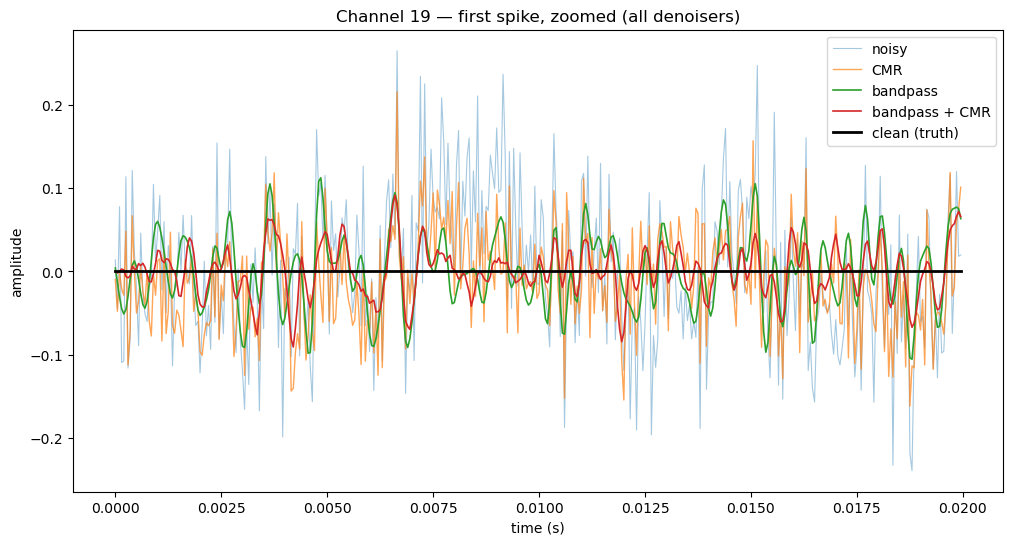

In [51]:
start = 0
end   = int(0.02 * fs)      # first 20 ms

plt.figure(figsize=(12, 6))
plt.plot(t_axis[start:end], noisy[ch, start:end],       lw=0.8, alpha=0.4, label="noisy")
plt.plot(t_axis[start:end], cmr[ch, start:end],         lw=1.0, alpha=0.7, label="CMR")
plt.plot(t_axis[start:end], bp[ch, start:end],          lw=1.2, label="bandpass")
plt.plot(t_axis[start:end], bp_then_cmr[ch, start:end], lw=1.2, label="bandpass + CMR")
plt.plot(t_axis[start:end], rec[ch, start:end],         lw=2.0, color='k', label="clean (truth)")
plt.xlabel("time (s)"); plt.ylabel("amplitude")
plt.title("Channel 19 — first spike, zoomed (all denoisers)")
plt.legend()
plt.show()

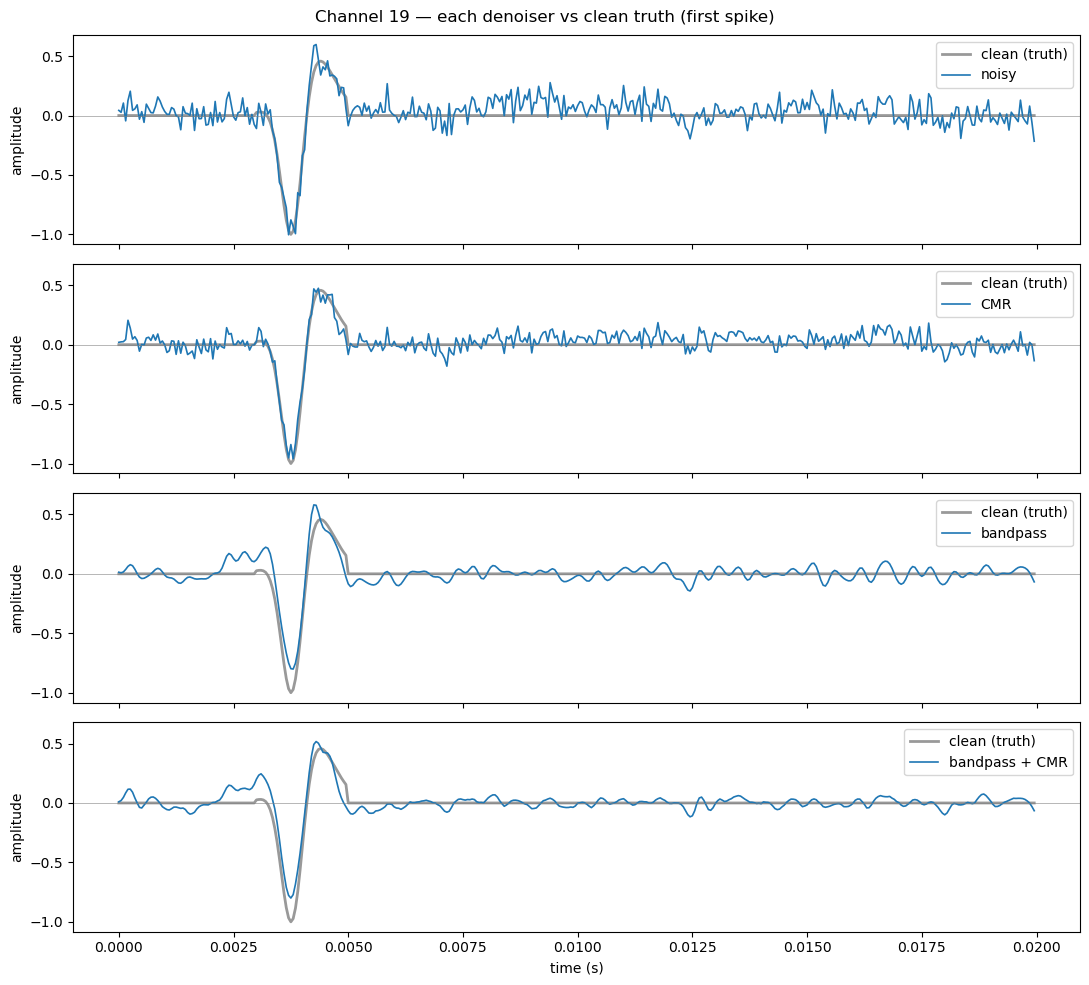

In [52]:
ch = 18   # channel 19
start = 0
end = int(0.02 * fs)      # first 20 ms (one spike)
t_zoom = t_axis[start:end]

traces = [
    ("noisy",           noisy),
    ("CMR",             cmr),
    ("bandpass",        bp),
    ("bandpass + CMR",  bp_then_cmr),
]

fig, axes = plt.subplots(len(traces), 1, figsize=(11, 10), sharex=True, sharey=True)

for ax, (name, data) in zip(axes, traces):
    ax.plot(t_zoom, rec[ch, start:end], lw=2.0, color='k', alpha=0.4, label="clean (truth)")
    ax.plot(t_zoom, data[ch, start:end], lw=1.2, label=name)
    ax.set_ylabel("amplitude")
    ax.legend(loc="upper right")
    ax.axhline(0, color='grey', lw=0.4)

axes[-1].set_xlabel("time (s)")
fig.suptitle("Channel 19 — each denoiser vs clean truth (first spike)")
plt.tight_layout()
plt.show()

In [53]:
#Sweep figure
cfs = [0.0, 0.25, 0.5, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0]

rmse_noisy_sweep, rmse_bp_sweep, rmse_cmr_sweep, rmse_both_sweep = [], [], [], [] 

for cf in cfs:
    noisy_cf = rec + make_noise(n_channels, n_samples, fs, common_frac=cf)
    rmse_noisy_sweep.append(rmse(noisy_cf, rec))
    rmse_bp_sweep.append(rmse(denoise_bandpass(noisy_cf, fs), rec))
    rmse_cmr_sweep.append(rmse(denoise_cmr(noisy_cf), rec))
    rmse_both_sweep.append(rmse(denoise_cmr(denoise_bandpass(noisy_cf, fs)), rec))
    print(f"cf={cf:.2f}")
                           
    

cf=0.00
cf=0.25
cf=0.50
cf=0.70
cf=0.75
cf=0.80
cf=0.85
cf=0.90
cf=0.95
cf=1.00


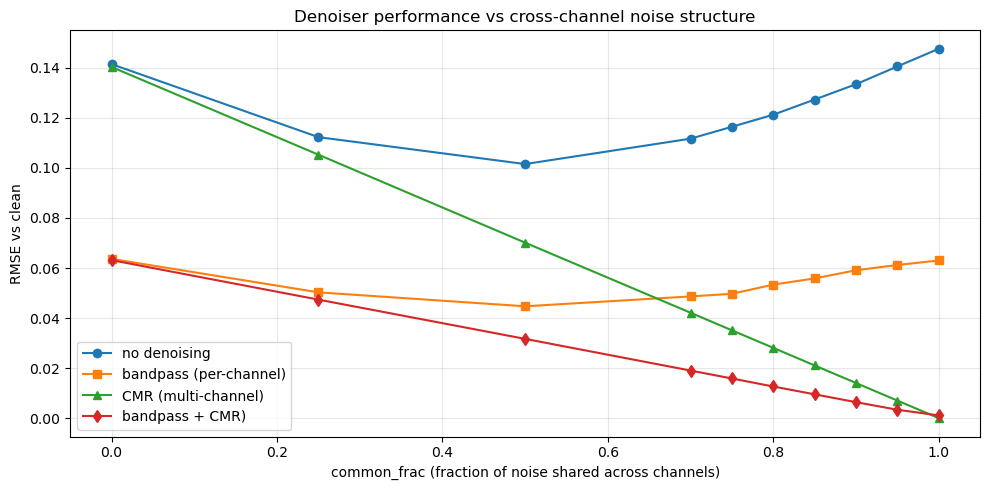

In [54]:
# plot
plt.figure(figsize=(10, 5))
plt.plot(cfs, rmse_noisy_sweep,  'o-', label="no denoising")
plt.plot(cfs, rmse_bp_sweep,  's-', label="bandpass (per-channel)")
plt.plot(cfs, rmse_cmr_sweep,  '^-',  label="CMR (multi-channel)")
plt.plot(cfs, rmse_both_sweep,  'd-',  label="bandpass + CMR)")
plt.xlabel("common_frac (fraction of noise shared across channels)")
plt.ylabel("RMSE vs clean")
plt.title("Denoiser performance vs cross-channel noise structure")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Common Average Reference (CAR)

In [55]:
def denoise_car(noisy, fs=None):
    """
    CAR is same as CMR above but uses the MEAN across channels instead of the median. 
    the mean is no not strong for ouliers, so large spike on one channel contaminates the reference and get subtracted from every channel. 
    """

    reference = np.mean(noisy, axis=0)
    denoised = noisy - reference
    return denoised

In [56]:
cf = 1.0
noisy_cf = rec + make_noise(n_channels, n_samples, fs, common_frac=cf)

car = denoise_car(noisy_cf)
cmr = denoise_cmr(noisy_cf)

print(f"common_frac = {cf}")
print("RMSE CAR:", rmse(car, rec))
print("RMSE CMR:", rmse(cmr, rec))
print()
print("channel,   clean,     CAR,     CMR")
for ch in [18, 24, 8, 2, 0]:
    print(f" ch{ch+1:2d},   {rec[ch].min():6.3f},   {car[ch].min():6.3f},    {cmr[ch].min():6.3f}")

common_frac = 1.0
RMSE CAR: 0.0015095336809407066
RMSE CMR: 1.8463196662364633e-19

channel,   clean,     CAR,     CMR
 ch19,   -1.000,   -0.863,    -1.000
 ch25,   -0.700,   -0.563,    -0.700
 ch 9,   -0.600,   -0.463,    -0.600
 ch 3,   -0.150,   -0.013,    -0.150
 ch 1,    0.000,   -0.063,     0.000


## Metric 3: cross-channel fidelity.

Per-channel denoising corrupts the cross-channel amplitude pattern, while joint denoising preserves it. However, both metrics above don't measure the patterns across channels' 
**RMSE**: measures noise removal
**spike_amplitude**: measures spike survival on one channel. 

**Cosine similarity** compares the shape of two vectors, ignoring overall scale. 
1.0 = identical patterns, fingerprint intact
Lower = pattern changed, fingerprint corrupted

-`channel_profil` - measures spike amplitude on all 32 channels, returns
the fingerprint as a 32-value vector. Uses `spike_amplitude` per channel.

-`cosine_similarity`: `dot(a,b) / (|a| x |b|)`. The dot product measures how much vectors point the same way; dividing by both lengths removes scale. 

-`fidelity` measures the clean fingerprint and the denoised fingerprint; return their cosine similarity. 

In [57]:
def channel_profile(data, spike_times, fs, n_channels, n_template=40):
    """
    Amplitude profile across all channels
    """
    return np.array([spike_amplitude(data[ch], spike_times, fs, n_template)
                                    for ch in range(n_channels)])

def cosine_similarity(a, b):
    """
    similarity of two vectors' shape, ignoring scale.
    """
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

def fidelity(denoised, clean, spike_times, fs, n_channels):
    """
    how well the cross channel survived denoising?
    """
    profile_clean = channel_profile(clean, spike_times, fs, n_channels)
    profile_denoised = channel_profile(denoised, spike_times, fs, n_channels)
    return cosine_similarity(profile_clean, profile_denoised)    

### Validation
from the CRA vs CMR experiment at common_frac=1.0

-**CMR** preserved every amplitude (-1.000, -0.700, -0.600, -0.150)

-**CAR** subtracted a constant 0.137 from every channel - ch19 lost %14, ch13 lost %91.


In [58]:
cf = 1.0
noisy_cf = rec + make_noise(n_channels, n_samples, fs, common_frac=cf)

print(f"common_frac = {cf}")
print("fidelity CMR: ", fidelity(denoise_cmr(noisy_cf), rec, dev_spikes, fs, n_channels))
print("fidelity CAR: ", fidelity(denoise_car(noisy_cf), rec, dev_spikes, fs, n_channels))

common_frac = 1.0
fidelity CMR:  1.0
fidelity CAR:  0.9567281411414739


#### The metric is valid because CMR showed an identical pattern (1.0), CAR was lower, as it detected the ratio damage that was already known to be there. 

### Repeat runs


In [59]:
noisy_05 = rec + make_noise(n_channels, n_samples, fs, common_frac=0.5)

print("\n common_frac = 0.5")
print("fidelity noisy:", fidelity(noisy_05, rec, dev_spikes, fs, n_channels))
print("fidelity bandpass:", fidelity(denoise_bandpass(noisy_05, fs), rec, dev_spikes, fs, n_channels))
print("fidelity CMR:", fidelity(denoise_cmr(noisy_05), rec, dev_spikes, fs, n_channels))
print("fidelity bandpass+CMR:", fidelity(denoise_cmr(denoise_bandpass(noisy_05, fs)), rec, dev_spikes, fs, n_channels))


 common_frac = 0.5
fidelity noisy: 0.8899469151136927
fidelity bandpass: 0.9557749399788846
fidelity CMR: 0.9214296689230341
fidelity bandpass+CMR: 0.9705658080543624


In [61]:
def repeat_fidelity(denoiser_function, cf, n_reps=5):
    """
    run a denoiser with fresh noise; return the mean and std of fidelity.
    """
    scores = []
    for _ in range(n_reps):
        noisy_rep = rec + make_noise(n_channels, n_samples, fs, common_frac=cf)
        denoised_rep = denoiser_function(noisy_rep)
        scores.append(fidelity(denoised_rep, rec, dev_spikes, fs, n_channels))
    return np.mean(scores), np.std(scores) 

cf = 0.5
methods = {
    "noisy": lambda x: x,
    "bandpass": lambda x: denoise_bandpass(x, fs),
    "CMR": lambda x: denoise_cmr(x),                          
    "bandpass+CMR": lambda x: denoise_cmr(denoise_bandpass(x, fs)),  
}

print(f"fidelity, common_frac={cf}, 5 reps")                
for name, function in methods.items():
    m, s = repeat_fidelity(function, cf, n_reps=20)           
    print(f"{name:14s}: {m:.4f}: +/- {s:.4f}")

fidelity, common_frac=0.5, 5 reps
noisy         : 0.9187: +/- 0.0102
bandpass      : 0.9599: +/- 0.0029
CMR           : 0.9292: +/- 0.0027
bandpass+CMR  : 0.9685: +/- 0.0011


In [62]:
np.random.seed(42)
noisy_t = rec + make_noise(n_channels, n_samples, fs, common_frac=0.5)

print(f"{'method':16s} {'RMSE':>8s} {'fidelity':>10s} {'ch19 %':>8s}")
for name, function in methods.items():
    d = function(noisy_t)
    r = rmse(d, rec)
    f = fidelity(d, rec, dev_spikes, fs, n_channels)
    a = spike_amplitude(d[18], dev_spikes, fs)
    pct = 100 * a / spike_amplitude(rec[18], dev_spikes, fs)
    print(f"{name:16s} {r:8.4f} {f:10.4f} {pct:7.0f}%")

method               RMSE   fidelity   ch19 %
noisy              0.1022     0.9268      99%
bandpass           0.0452     0.9624      85%
CMR                0.0702     0.9247      97%
bandpass+CMR       0.0316     0.9688      82%


### Conclusion
bandpass+CMR is best. It removes the most noise (RMSE 0.032) and preserves the cross-channel fingerprint best (0.969). It costs ~18% of spike amplitude, but that cost buys 69% noise reduction, and the fingerprint (which sorting depends on) survives.

**On the spike-preservation column:** it ranks the methods backwards (noisy 99% > CMR 97% > bandpass 85% > bandpass+CMR 82%). This measures the *cost* of denoising. Doing nothing preserves 99% of the spike because nothing was done to it; it also removes 0% of the noise. 

**This is the denoising trade-off:** removing noise costs signal. Bandpass discards frequencies outside 300–3000 Hz, and some of the spike's own energy lives out there. Every denoiser trades noise removal against signal damage.

**None of these three metrics settles the trade-off.** Is 18% spike loss worth 69% noise removal? RMSE implies yes; spike preservation implies no. Neither actually knows, because all three are signal-level proxies.

**Detection F1** will telll whether the spikes will be found. 

In [63]:
#SNR
def snr_db(signal_amp, noise_std):
    return 20 * np.log10(np.abs(signal_amp) / noise_std)

In [64]:
noisy_table = rec + make_noise(n_channels, n_samples, fs, common_frac=0.5)

print(f"{'method':16s} {'RMSE':>8s} {'fidelity':>10s} {'ch19 %':>8s} {'SNR':>8s}")
for name, function in methods.items():
    d = function(noisy_table)
    r = rmse(d, rec)
    f = fidelity(d, rec, dev_spikes, fs, n_channels)
    a = spike_amplitude(d[18], dev_spikes, fs)
    pct = 100 * a / spike_amplitude(rec[18], dev_spikes, fs)
    snr_val = snr_db(a, d[0].std())
    print(f"{name:16s} {r:8.4f} {f:10.4f} {pct:7.0f}% {snr_val:8.1f}")

method               RMSE   fidelity   ch19 %      SNR
noisy              0.1024     0.9233     103%     20.1
bandpass           0.0454     0.9577      84%     25.5
CMR                0.0701     0.9298      98%     23.0
bandpass+CMR       0.0316     0.9680      82%     28.6


# Step 3: Spike detection 
RMSE, fidelity, spike_amplitude and SNR are all **signal-level proxies**. They measure properties of the waveform and hope those translate into a working pipeline. None answers the question the pipeline exists for: **can you find the spikes?**

The four-metric table showed why this matters because they disagree. RMSE, SNR and fidelity all rank bandpass+CMR best; ch19 % ranks it worst (83% vs 102% for doing nothing). Is 17% spike loss worth 69% noise reduction?.

 Run a detector on the denoised signal, compare its findings to the known ground-truth spike times, and score it.

### WHat does the detector do?
The detector draws a horizontal line below zero (the threshold) and flags each moment the signal first crosses below it. 


In [65]:
def detect_spikes(data, fs, k=4, noise_std=None):
    """
    Threshold detector per channel. flags where the signal dipes below -k * noise_std.
    groups consecutive below threshold samples inro a signal detections. return detection times in seconds.
    """
    if noise_std is None:
        noise_std = data.std()   # rough estimate

    threshold = -k * noise_std
    below = data < threshold  # true/false array : is each samples below threshold? 

    # find where below turns false to true
    crossings = np.where(np.diff(below.astype(int)) == 1)[0] + 1
    return crossings / fs  # convert sample index to seconds

In [66]:
ch = 18
detections = detect_spikes(denoised[ch], fs, k=6)
print("detected:", len(detections), "spikes")
print("true:", len(dev_spikes), "spikes")
print("frist 3 detcted (s):", detections[:3])
print("first 3 true (s): ", dev_spikes[:3])

detected: 10 spikes
true: 10 spikes
frist 3 detcted (s): [3.50000e-03 4.00355e+00 8.00355e+00]
first 3 true (s):  [3.000e-03 4.003e+00 8.003e+00]


**The grouping problem:** a spike is ~40 samples wide, so many consecutive samples sit below the line. Flagging each would give ~20 detections per spike. `np.diff(below.astype(int)) == 1` finds only where the signal *enters* the below-threshold region; one detection per spike. 

### Choosing k (the threshold trade-off)

| k | threshold | detections | true |
|---|---|---|---|
| 4 | ≈ -0.18 | **25** | 10 |
| 6 | ≈ -0.27 | **10** | 10 |

**k=4:** the line sits close enough to the noise that noise wiggles occasionally dip past it. 10 real spikes + 15 noise crossings = 25.

**k=6:** the line is beyond the noise's reach. Real spikes (-0.86 after denoising) still sail past. 10 detections, all real.

**The trade-off:**
- Threshold too shallow (low k) -> catches every real spike, but also noise → **false positives**
- Threshold too deep (high k) -> excludes noise, but weak spikes don't reach it either → **missed spikes**

**Note:** k=6 works on channel 19, where the spike (-0.86) is 3× deeper than the threshold. On channel 3 (spike -0.15, *shallower* than the -0.27 threshold), k=6 would not find anything. No single k catches ch3's spike without drowning in noise on ch19. 

### Timing offset
Every detection is ~0.5 ms **late**, consistently.

**Why:** the ground truth is marked at the zero crossing, where the waveform *starts* its descent. The detector fires when the signal has descended far enough to cross the threshold, which is partway down. The gap is the time it takes the waveform to fall from 0 to -0.27.

**Why it's consistent:** every spike is the same waveform, so every spike takes the same time to reach the threshold.

**Consequence:** F1 must use a **tolerance window**; a detection within ±X ms of a true spike counts as a hit. With a 0.5 ms offset, ±1 ms is comfortable. Demanding exact matches would score all 10 correct detections as misses.

Note: raising k lengthens the lag (further to descend), so k affects timing as well as count.

### limitation

k=6 was found by trying values and watching the detection count reach 10. **That only works because the answer is known in synthetic data.** On real data there is no true count to tune against.

The field's standard is anoise estimator: **MAD** (median absolute deviation):
### MAD is:
The median ignores outliers (same logic as CMR ignoring spikes), so it estimates the noise floor correctly *without* knowing where the spikes are. A fixed k of 4–5 then works without tuning.

The current detector also uses `data.std()` as its noise estimate, which is inflated by the spikes themselves. Both should be replaced with MAD before this transfers to real data.

## F1 Detection Scoring the detection
The detector produces a list of times. F1 asks whether that list is right, by comparing it to the known ground-truth spike times.

### The three counts

- **TP** (true positive) — a detection matching a real spike
- **FP** (false positive) — a detection with no real spike near it
- **FN** (false negative) — a real spike the detector missed

### Tolerance window

Detections are ~0.5 ms late (threshold crossing vs zero-crossing convention). Exact matching would score every correct detection as a miss. So a detection within **±1 ms** of a true spike counts as a match.

The `matched_true` set stops one true spike being claimed by two detections; each true spike can be found once.

### The three scores

**Precision** = TP / (TP + FP): of what I found, how much was real? Measures false alarms.

**Recall** = TP / (TP + FN): of what's real, how much did I find? Measures misses.

**F1** = 2 × (P × R) / (P + R): combines both.

**F1 grades; precision and recall diagnose:**
- Low precision, high recall → threshold too shallow, drowning in false alarms → raise k
- High precision, low recall → threshold too deep, missing spikes → lower k

In [67]:
def score_detections(detected, true_times, tolerance=0.001):
    """
    Match detections to true spike times within a tolerance window (seconds).
    """
    matched_true = set()  # which true spikes have been found
    tp = 0

    for d in detected:
        # find true spikes within tolerance of this detection 
        close = np.where(np.abs(true_times - d) <= tolerance)[0]
        # only keep onse not already matched
        unmatched = [i for i in close if i not in matched_true]
        if len(unmatched) > 0:
            tp += 1
            matched_true.add(unmatched[0]) 
    fp = len(detected) - tp
    fn = len(true_times) - len(matched_true)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    return precision, recall, f1

In [68]:
ch = 18
detections = detect_spikes(denoised[ch], fs, k=6)
p, r, f = score_detections(detections, dev_spikes)
print(f"detected {len(detections)}, true {len(dev_spikes)}")
print(f"precision {p:.3f}  recall {r:.3f}  F1 {f:.3f}")

detected 10, true 10
precision 1.000  recall 1.000  F1 1.000


In [69]:
detections_k4 = detect_spikes(denoised[ch], fs, k=4)
p, r, f = score_detections(detections_k4, dev_spikes)
print(f"k=4: detected {len(detections_k4)}, precision {p:.3f}  recall {r:.3f}  F1 {f:.3f}")

k=4: detected 25, precision 0.400  recall 1.000  F1 0.571


### Results: channel 19

| k | detected | precision | recall | F1 |
|---|---|---|---|---|
| 4 | 25 | 0.400 | 1.000 | 0.571 |
| 6 | 10 | 1.000 | 1.000 | **1.000** |

**k=4:** found all 10 real spikes (recall 1.0) plus 15 noise crossings. Only 40% of its output was real.

**Note what recall alone would have said:** 1.000 "perfect detector." It hid the 15 phantoms completely. F1 (0.571) gives the honest verdict.

**Why false positives matter:** they get passed to the sorter, producing phantom units, corrupted templates, and inflated firing rates. For this project, that could mean reporting nociceptor activity that does not exist.

**k=6:** threshold deep enough to exclude noise, still shallow enough for real spikes (-0.86). Perfect.

### questions
F1 = 1.000 on channel 19, where the spike is 3× deeper than the threshold. The open questions:
1. Does denoising improve F1, or was it already 1.0 without it?
2. Channel 3 (spike -0.15, shallower than the -0.27 threshold): expect F1 = 0.
3. If ch19 is trivially perfect, raise the noise until detection starts failing, then compare denoisers.

In [70]:
# Q1. does denoising improve F1 on channel 19?
np.random.seed(42)
noisy_detection = rec + make_noise(n_channels, n_samples, fs, common_frac=0.5)

ch = 18
print(f"{'method':16s} {'detected':>9s} {'precisio':>7s} {'recall':>8s} {'F1':>7s}")
for name, function in methods.items():
    denoised_data = function(noisy_detection)
    detections = detect_spikes(denoised_data[ch], fs, k=6)
    precision, recall, f1 = score_detections(detections, dev_spikes)
    print(f"{name:16s} {len(detections):9d} {precision:7.3f} {recall:8.3f} {f1:7.3f}")

method            detected precisio   recall      F1
noisy                   11   0.909    1.000   0.952
bandpass                10   1.000    1.000   1.000
CMR                     10   1.000    1.000   1.000
bandpass+CMR            10   1.000    1.000   1.000


In [71]:
# Q2. what about channel 3 (the weakest channel?
ch = 2
print(f"channel 3 (weak: spike -0.15)")
print(f"{'method':16s} {'detected':>9s} {'prec':>7s} {'recall':>8s} {'F1':>7s}")
for name, function in methods.items():
    denoised_data = function(noisy_detection)
    detections = detect_spikes(denoised_data[ch], fs, k=6)
    precision, recall, f1 = score_detections(detections, dev_spikes)
    print(f"{name:16s} {len(detections):9d} {precision:7.3f} {recall:8.3f} {f1:7.3f}")

channel 3 (weak: spike -0.15)
method            detected    prec   recall      F1
noisy                    0   0.000    0.000   0.000
bandpass                 0   0.000    0.000   0.000
CMR                      0   0.000    0.000   0.000
bandpass+CMR             0   0.000    0.000   0.000


In [72]:
#Q3. 
print(f"\n Channel 19, higher noise")
for noise_level in [0.1, 0.2, 0.3, 0.4]:
    print(f"\nnoise_std = {noise_level}")
    np.random.seed(42)
    noisy_h = rec + make_noise(n_channels, n_samples, fs,
                               white_std=noise_level, pink_std=noise_level,
                               common_frac=0.5)
    for name, function in methods.items():
        denoised_data = function(noisy_h)
        detections = detect_spikes(denoised_data[18], fs, k=6)
        precision, recall, f1 = score_detections(detections, dev_spikes)
        print(f"  {name:16s} {len(detections):5d} detections, F1 {f1:.3f}")


 Channel 19, higher noise

noise_std = 0.1
  noisy               11 detections, F1 0.952
  bandpass            10 detections, F1 1.000
  CMR                 10 detections, F1 1.000
  bandpass+CMR        10 detections, F1 1.000

noise_std = 0.2
  noisy                3 detections, F1 0.308
  bandpass            10 detections, F1 1.000
  CMR                 13 detections, F1 0.696
  bandpass+CMR        10 detections, F1 1.000

noise_std = 0.3
  noisy                0 detections, F1 0.000
  bandpass             8 detections, F1 0.889
  CMR                  1 detections, F1 0.182
  bandpass+CMR        10 detections, F1 1.000

noise_std = 0.4
  noisy                0 detections, F1 0.000
  bandpass             2 detections, F1 0.333
  CMR                  0 detections, F1 0.000
  bandpass+CMR         7 detections, F1 0.824


# Wavelet

In [73]:
import pywt
print(pywt.__version__)

1.8.0


In [74]:
import pywt

In [97]:
def denoise_wavelet_channel(x, wavelet='db4', level=4, thresh_scale=0.3):
    """
    SWT denoising for one channel.
    Decompose -> universal-threshold the detail coeffs -> reconstruct.
    Matches kechris et al.'s db4 / level 4/ sqtwolog / sorf config.
    """
    n = len(x)

    # first decompose into wavelet coefficients
    coeffs = pywt.wavedec(x, wavelet, level=level)
    # second, estimate noise sigma from the finest detail coeffs (MAD)
    sigma = np.median(np.abs(coeffs[-1])) / 0.6745
    # third, threshold: sigma * sqrt(2 * ln(N))
    threshold = sigma * np.sqrt(2 * np.log(n))
    # fourth, soft-threshold every detial level, but leav approximation.
    new_coeffs = [coeffs[0]]  
    for c in coeffs[1:]:
        new_coeffs.append(pywt.threshold(c, threshold, mode='soft'))

    #fifth, reconstruct
    denoised = pywt.waverec(new_coeffs, wavelet)

    # sixth, waverec can return 1 sample too many (padding); trim to match input
    return denoised[:n]

def denoise_wavelet(noisy, fs=None, wavelet='db4', level=4):
    """
    DWT denoising for all channels, per-channel.
    """

    out = np.zeros_like(noisy)
    for ch in range(noisy.shape[0]):
        out[ch] = denoise_wavelet_channel(noisy[ch], wavelet, level)
    return out
    

In [98]:
np.random.seed(42)
noisy_w = rec + make_noise(n_channels, n_samples, fs,
                           white_std=0.3, pink_std=0.3, common_frac=0.5)  # noise 0.3, hard regime

ch = 18

wav = denoise_wavelet(noisy_w, fs)
bp  = denoise_bandpass(noisy_w, fs)

print("channel 19, noise 0.3")
print(f"{'method':10s} {'RMSE':>8s} {'F1':>7s}")
for name, d in [("noisy", noisy_w), ("bandpass", bp), ("wavelet", wav)]:
    r = rmse(d[ch], rec[ch])
    det = detect_spikes(d[ch], fs, k=6)
    _, _, f = score_detections(det, dev_spikes)
    print(f"{name:10s} {r:8.4f} {f:7.3f}")


channel 19, noise 0.3
method         RMSE      F1
noisy        0.3002   0.000
bandpass     0.1348   0.889
wavelet      0.1961   0.000


In [92]:
x = noisy_w[18]
print("input length:", len(x))

coeffs = pywt.wavedec(x, 'db4', level=4)
print("n coeff arrays:", len(coeffs))
print("coeff lengths:", [len(c) for c in coeffs])

sigma = np.median(np.abs(coeffs[-1])) / 0.6745
threshold = sigma * np.sqrt(2 * np.log(len(x)))
print("sigma:", sigma, "threshold:", threshold)

new_coeffs = [coeffs[0]] + [pywt.threshold(c, threshold, mode='soft') for c in coeffs[1:]]
rec_test = pywt.waverec(new_coeffs, 'db4')
print("reconstructed length:", len(rec_test))

input length: 720260
n coeff arrays: 5
coeff lengths: [45022, 45022, 90038, 180070, 360133]
sigma: 0.2234573391486286 threshold: 1.1605750157385277
reconstructed length: 720260


In [100]:
np.random.seed(42)
noisy_w = rec + make_noise(n_channels, n_samples, fs,
                           white_std=0.3, pink_std=0.3, common_frac=0.5)
ch = 18

def wavelet_scaled(x, scale, wavelet='db4', level=4):
    n = len(x)
    coeffs = pywt.wavedec(x, wavelet, level=level)
    sigma = np.median(np.abs(coeffs[-1])) / 0.6745
    threshold = scale * sigma * np.sqrt(2 * np.log(n))
    new_coeffs = [coeffs[0]] + [pywt.threshold(c, threshold, mode='soft') for c in coeffs[1:]]
    return pywt.waverec(new_coeffs, wavelet)[:n]

print(f"{'method':16s} {'RMSE':>8s} {'F1':>7s}")

# baselines
r = rmse(noisy_w[ch], rec[ch]); _,_,f = score_detections(detect_spikes(noisy_w[ch], fs, k=6), dev_spikes)
print(f"{'noisy':16s} {r:8.4f} {f:7.3f}")
bpd = denoise_bandpass(noisy_w, fs)
r = rmse(bpd[ch], rec[ch]); _,_,f = score_detections(detect_spikes(bpd[ch], fs, k=6), dev_spikes)
print(f"{'bandpass':16s} {r:8.4f} {f:7.3f}")

# wavelet at different threshold scales
for scale in [1.0, 0.5, 0.3, 0.2, 0.1]:
    d = wavelet_scaled(noisy_w[ch], scale)
    r = rmse(d, rec[ch])
    _,_,f = score_detections(detect_spikes(d, fs, k=6), dev_spikes)
    print(f"{'wavelet s=' + str(scale):16s} {r:8.4f} {f:7.3f}")

method               RMSE      F1
noisy              0.3002   0.000
bandpass           0.1348   0.889
wavelet s=1.0      0.1961   0.000
wavelet s=0.5      0.1965   0.000
wavelet s=0.3      0.2026   0.000
wavelet s=0.2      0.2158   0.000
wavelet s=0.1      0.2458   0.000


In [101]:
d = wavelet_scaled(noisy_w[18], 0.3)

print("clean spike trough:   ", rec[18].min())
print("wavelet spike trough: ", d.min())
print("wavelet output std:   ", d.std())
print("noisy std:            ", noisy_w[18].std())

# what threshold does detection use on the wavelet output?
print("detect threshold:     ", -6 * d.std())

clean spike trough:    -1.0
wavelet spike trough:  -1.1454224807244864
wavelet output std:    0.20276367221949526
noisy std:             0.3003866751832083
detect threshold:      -1.2165820333169717


In [102]:
d = wavelet_scaled(denoise_bandpass(noisy_w, fs)[18], 0.5)
r = rmse(d, rec[18])
_,_,f = score_detections(detect_spikes(d, fs, k=6), dev_spikes)
print(f"bandpass+wavelet: RMSE {r:.4f}, F1 {f:.3f}")

bandpass+wavelet: RMSE 0.1225, F1 0.947


In [103]:
ch = 18
print(f"{'method':22s} {'RMSE':>8s} {'F1':>7s}")

# bandpass alone 
bp = denoise_bandpass(noisy_w, fs)[ch]
r = rmse(bp, rec[ch]); _,_,f = score_detections(detect_spikes(bp, fs, k=6), dev_spikes)
print(f"{'bandpass':22s} {r:8.4f} {f:7.3f}")

# wavelet alone
w = wavelet_scaled(noisy_w[ch], 0.5)
r = rmse(w, rec[ch]); _,_,f = score_detections(detect_spikes(w, fs, k=6), dev_spikes)
print(f"{'wavelet':22s} {r:8.4f} {f:7.3f}")

# bandpass THEN wavelet
bw = wavelet_scaled(denoise_bandpass(noisy_w, fs)[ch], 0.5)
r = rmse(bw, rec[ch]); _,_,f = score_detections(detect_spikes(bw, fs, k=6), dev_spikes)
print(f"{'bandpass+wavelet':22s} {r:8.4f} {f:7.3f}")

method                     RMSE      F1
bandpass                 0.1348   0.889
wavelet                  0.1965   0.000
bandpass+wavelet         0.1225   0.947


In [104]:
bp = denoise_bandpass(noisy_w, fs)[18]
for scale in [1.0, 0.5, 0.3]:
    bw = wavelet_scaled(bp, scale)
    r = rmse(bw, rec[18])
    _,_,f = score_detections(detect_spikes(bw, fs, k=6), dev_spikes)
    print(f"bandpass+wavelet s={scale}: RMSE {r:.4f}, F1 {f:.3f}")

bandpass+wavelet s=1.0: RMSE 0.1121, F1 0.947
bandpass+wavelet s=0.5: RMSE 0.1225, F1 0.947
bandpass+wavelet s=0.3: RMSE 0.1271, F1 0.947


## Wavelet denoising (single-channel)

DWT via PyWavelets: decompose (`wavedec`) -> soft-threshold detail coefficients -> reconstruct (`waverec`). Config from Kechris et al.: db4, level 4, universal threshold (σ√(2 ln N)), soft. σ estimated by MAD from the finest detail coefficients.

### Result — channel 19, noise_std 0.3

| method | RMSE | F1 |
|---|---|---|
| noisy | 0.300 | 0.000 |
| wavelet alone | 0.196 | 0.000 |
| bandpass alone | 0.135 | 0.889 |
| **bandpass + wavelet** | **0.112** | **0.947** |

**Wavelet alone fails (F1 = 0).** Not because it damages the spike, the spike trough survives intact (-1.15). It fails because wavelet thresholds only the *detail* (high-frequency) coefficients and leaves the *approximation* (low-frequency) untouched. The pink (1/f) noise is dominated by low frequencies, so it lives in the approximation and passes straight through. The residual drift keeps the signal std high (0.20 vs the bandpass's much lower), which inflates the detection threshold (-6×std = -1.22) *deeper than the spike itself* (-1.15) — so nothing crosses, and F1 = 0.

**Bandpass + wavelet is the best single-channel method.** Bandpass removes the low-frequency drift wavelet can't touch; wavelet then removes the in-band residual bandpass leaves behind. Complementary, same as bandpass+CMR. F1 rises 0.889 -> 0.947, RMSE falls 0.135 -> 0.112.

**Robust to threshold scale:** F1 = 0.947 at scales 1.0, 0.5, 0.3. RMSE is best at full scale (1.0). The universal threshold is not too aggressive after all — it only appeared so when fighting the drift. With drift removed first, the full threshold is correct.

**in conclusion:** wavelet is not a standalone denoiser for 1/f-heavy data, it is a refinement stage after filtering. This matches its use in the literature (a pipeline step, not a replacement for the bandpass).